# LAB 05: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)

Sử dụng các kỹ thuật phân đoạn ảnh khác nhau trên ảnh `dog.png`.

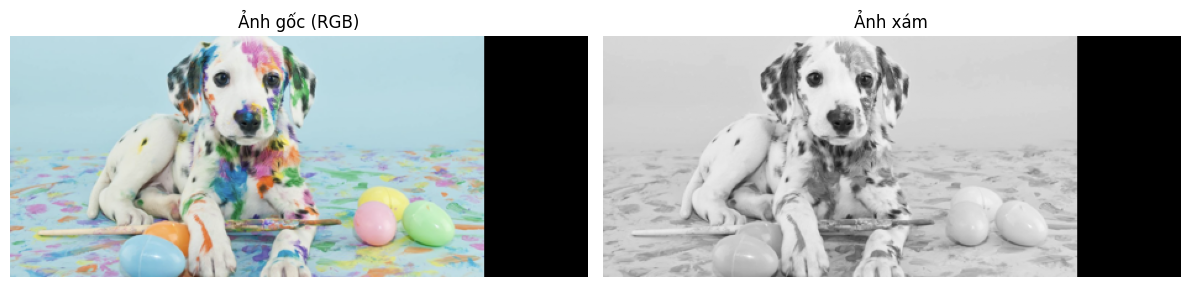

Kích thước ảnh: (195, 468, 3)


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage.segmentation import flood
from collections import deque

# Đọc ảnh
img = cv.imread('dog.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title('Ảnh gốc (RGB)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(gray, cmap='gray'); plt.title('Ảnh xám'); plt.axis('off')
plt.tight_layout(); plt.show()
print(f"Kích thước ảnh: {img.shape}")

## 1. Thresholding để phân đoạn ảnh

Phương pháp đơn giản nhất: chọn ngưỡng (threshold) để phân chia pixel thành 2 nhóm (foreground/background).

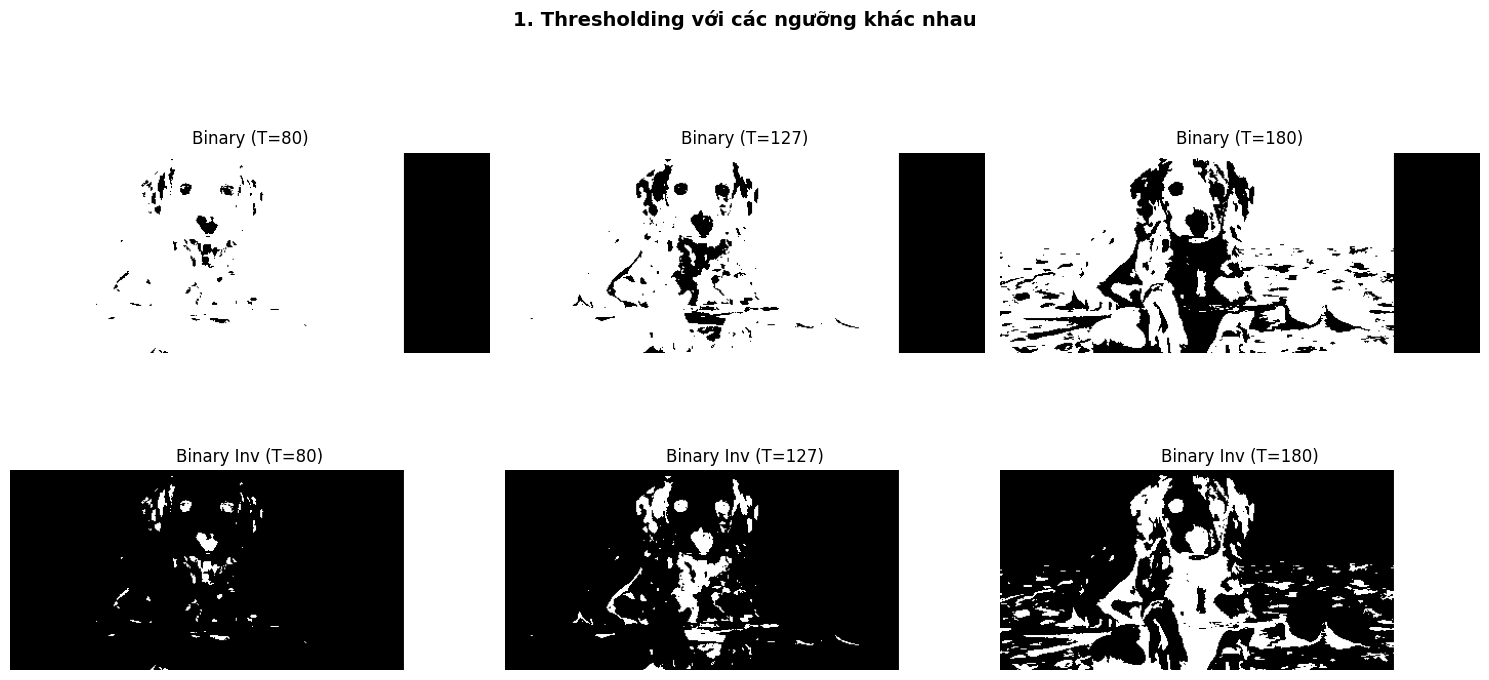

In [2]:
# Binary Thresholding với các ngưỡng khác nhau
thresholds = [80, 127, 180]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, thresh_val in enumerate(thresholds):
    _, binary = cv.threshold(gray, thresh_val, 255, cv.THRESH_BINARY)
    _, binary_inv = cv.threshold(gray, thresh_val, 255, cv.THRESH_BINARY_INV)
    axes[0, i].imshow(binary, cmap='gray'); axes[0, i].set_title(f'Binary (T={thresh_val})'); axes[0, i].axis('off')
    axes[1, i].imshow(binary_inv, cmap='gray'); axes[1, i].set_title(f'Binary Inv (T={thresh_val})'); axes[1, i].axis('off')

plt.suptitle('1. Thresholding với các ngưỡng khác nhau', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

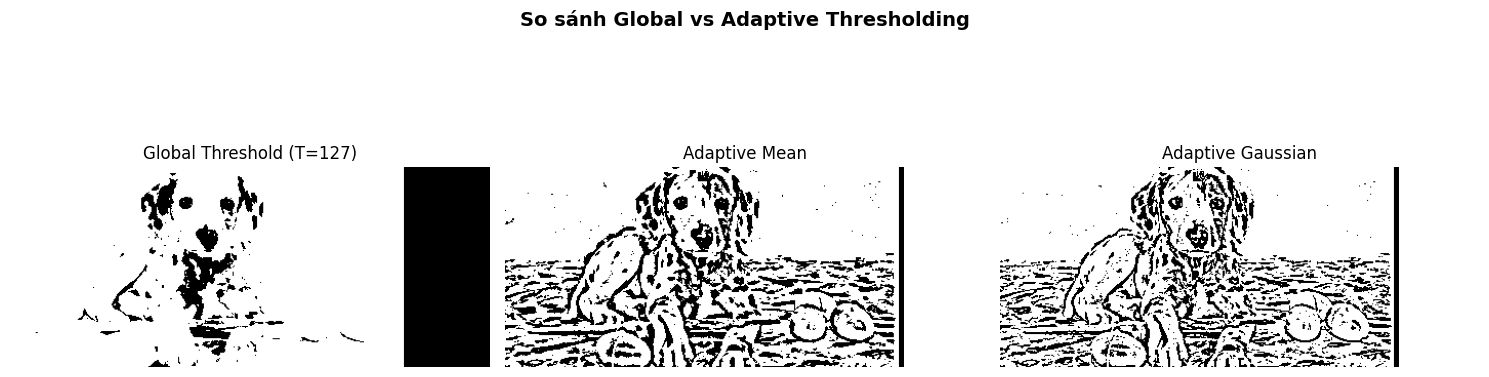

In [3]:
# Adaptive Thresholding
adaptive_mean = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 2)
adaptive_gauss = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)
_, global_thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(global_thresh, cmap='gray'); axes[0].set_title('Global Threshold (T=127)')
axes[1].imshow(adaptive_mean, cmap='gray'); axes[1].set_title('Adaptive Mean')
axes[2].imshow(adaptive_gauss, cmap='gray'); axes[2].set_title('Adaptive Gaussian')
for ax in axes: ax.axis('off')
plt.suptitle('So sánh Global vs Adaptive Thresholding', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Otsu Algorithm để phân đoạn ảnh

Otsu tự động tìm ngưỡng tối ưu bằng cách tối thiểu hóa phương sai nội lớp (intra-class variance).

Thường dùng cho ảnh vân tay, ảnh có bimodal histogram.

/var/folders/7_/z9mr28ld51z7c71nzvq93bm40000gn/T/ipykernel_22343/1379144298.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1,0].hist(gray.ravel(), 256, [0,256], color='steelblue'); axes[1,0].set_title('Histogram ảnh gốc')
/var/folders/7_/z9mr28ld51z7c71nzvq93bm40000gn/T/ipykernel_22343/1379144298.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1,1].hist(gray.ravel(), 256, [0,256], color='steelblue'); axes[1,1].set_title('Histogram + Otsu threshold')
/var/folders/7_/z9mr28ld51z7c71nzvq93bm40000gn/T/ipykernel_22343/1379144298.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1,2].hist(blur.ravel(), 2

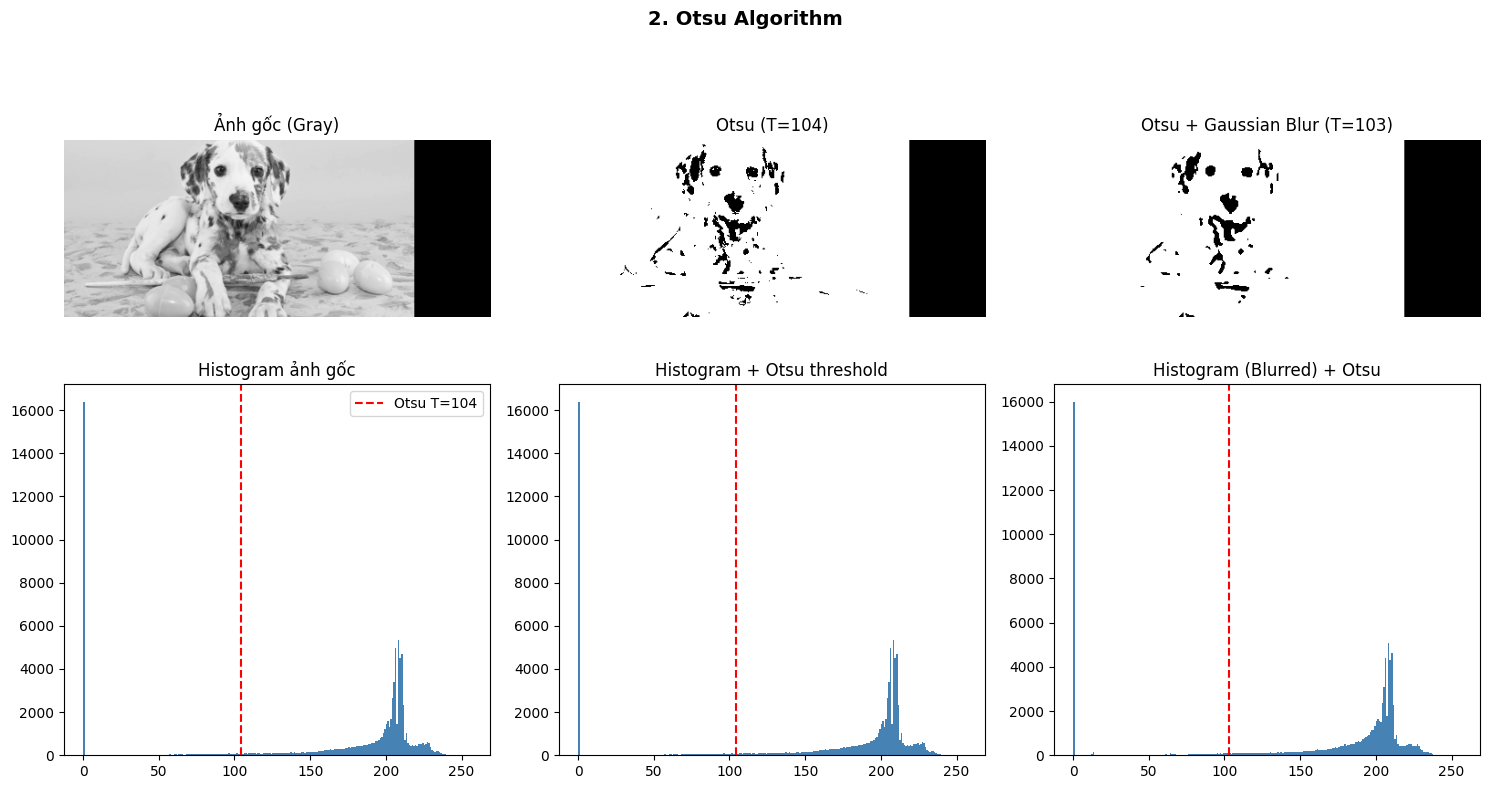

Ngưỡng Otsu (không blur): 104
Ngưỡng Otsu (có Gaussian blur): 103


In [4]:
# Otsu's Thresholding
ret_otsu, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
# Otsu sau khi lọc Gaussian
blur = cv.GaussianBlur(gray, (5, 5), 0)
ret_otsu_blur, otsu_blur = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# Hàng 1: ảnh
axes[0,0].imshow(gray, cmap='gray'); axes[0,0].set_title('Ảnh gốc (Gray)')
axes[0,1].imshow(otsu, cmap='gray'); axes[0,1].set_title(f'Otsu (T={ret_otsu:.0f})')
axes[0,2].imshow(otsu_blur, cmap='gray'); axes[0,2].set_title(f'Otsu + Gaussian Blur (T={ret_otsu_blur:.0f})')
# Hàng 2: histogram
axes[1,0].hist(gray.ravel(), 256, [0,256], color='steelblue'); axes[1,0].set_title('Histogram ảnh gốc')
axes[1,0].axvline(x=ret_otsu, color='red', linestyle='--', label=f'Otsu T={ret_otsu:.0f}')
axes[1,0].legend()
axes[1,1].hist(gray.ravel(), 256, [0,256], color='steelblue'); axes[1,1].set_title('Histogram + Otsu threshold')
axes[1,1].axvline(x=ret_otsu, color='red', linestyle='--')
axes[1,2].hist(blur.ravel(), 256, [0,256], color='steelblue'); axes[1,2].set_title('Histogram (Blurred) + Otsu')
axes[1,2].axvline(x=ret_otsu_blur, color='red', linestyle='--')
for ax in axes.flat: ax.axis('off') if ax in axes[0] else None
plt.suptitle('2. Otsu Algorithm', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Ngưỡng Otsu (không blur): {ret_otsu:.0f}")
print(f"Ngưỡng Otsu (có Gaussian blur): {ret_otsu_blur:.0f}")

## 3. K-Means Clustering để phân đoạn ảnh

Phân đoạn ảnh dựa trên màu sắc bằng cách gom nhóm (clustering) các pixel có giá trị màu tương tự.

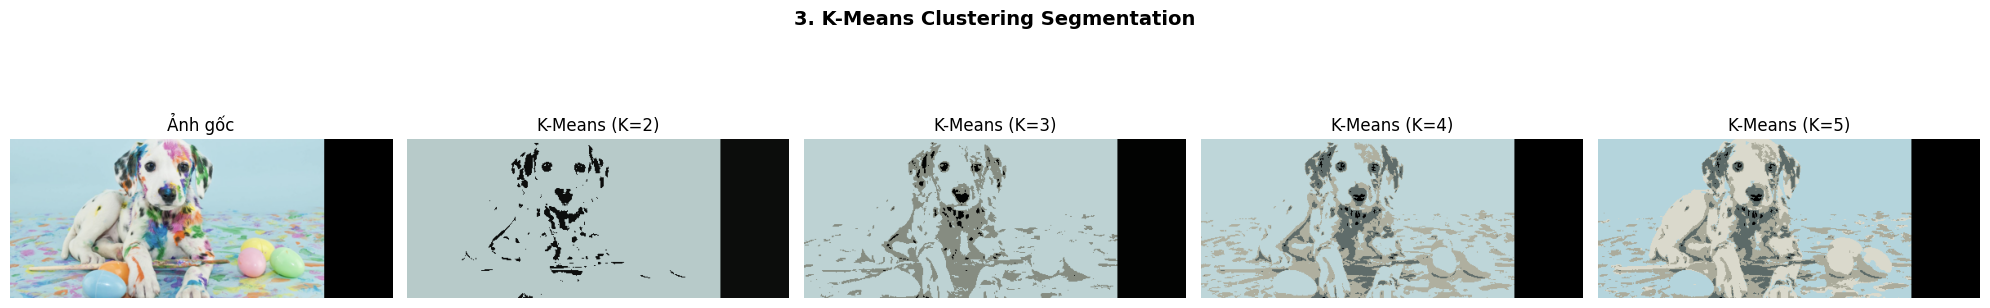

In [5]:
# K-Means Clustering
pixel_values = img_rgb.reshape((-1, 3)).astype(np.float32)

# Thử với K = 2, 3, 4, 5
K_values = [2, 3, 4, 5]
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

fig, axes = plt.subplots(1, len(K_values) + 1, figsize=(20, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Ảnh gốc'); axes[0].axis('off')

for i, K in enumerate(K_values):
    _, labels, centers = cv.kmeans(pixel_values, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented = centers[labels.flatten()].reshape(img_rgb.shape)
    axes[i+1].imshow(segmented); axes[i+1].set_title(f'K-Means (K={K})'); axes[i+1].axis('off')

plt.suptitle('3. K-Means Clustering Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

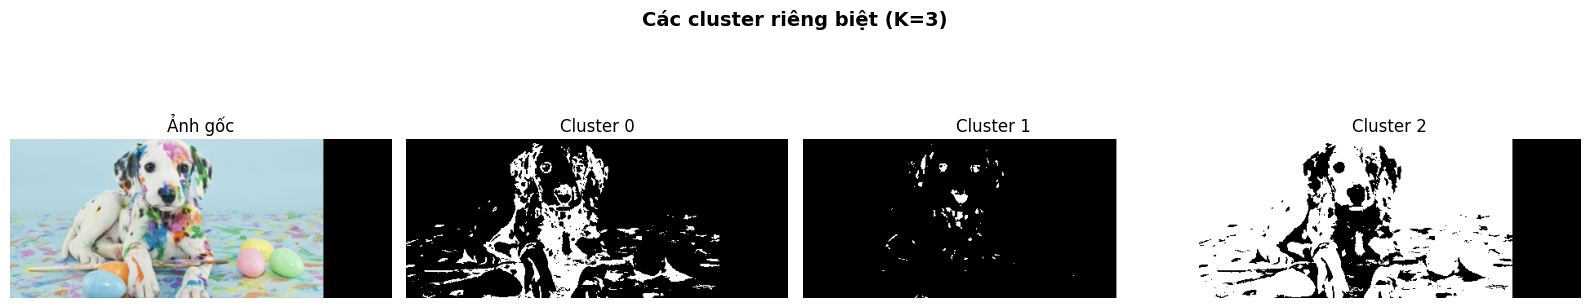

In [6]:
# Hiển thị các cluster riêng biệt cho K=3
K = 3
_, labels, centers = cv.kmeans(pixel_values, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
labels_2d = labels.reshape(gray.shape)

fig, axes = plt.subplots(1, K + 1, figsize=(16, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Ảnh gốc'); axes[0].axis('off')
for k in range(K):
    mask = (labels_2d == k).astype(np.uint8) * 255
    axes[k+1].imshow(mask, cmap='gray'); axes[k+1].set_title(f'Cluster {k}'); axes[k+1].axis('off')
plt.suptitle(f'Các cluster riêng biệt (K={K})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Region Growing

Bắt đầu từ seed point, mở rộng vùng bằng cách thêm pixel lân cận có giá trị tương tự (trong ngưỡng cho phép).

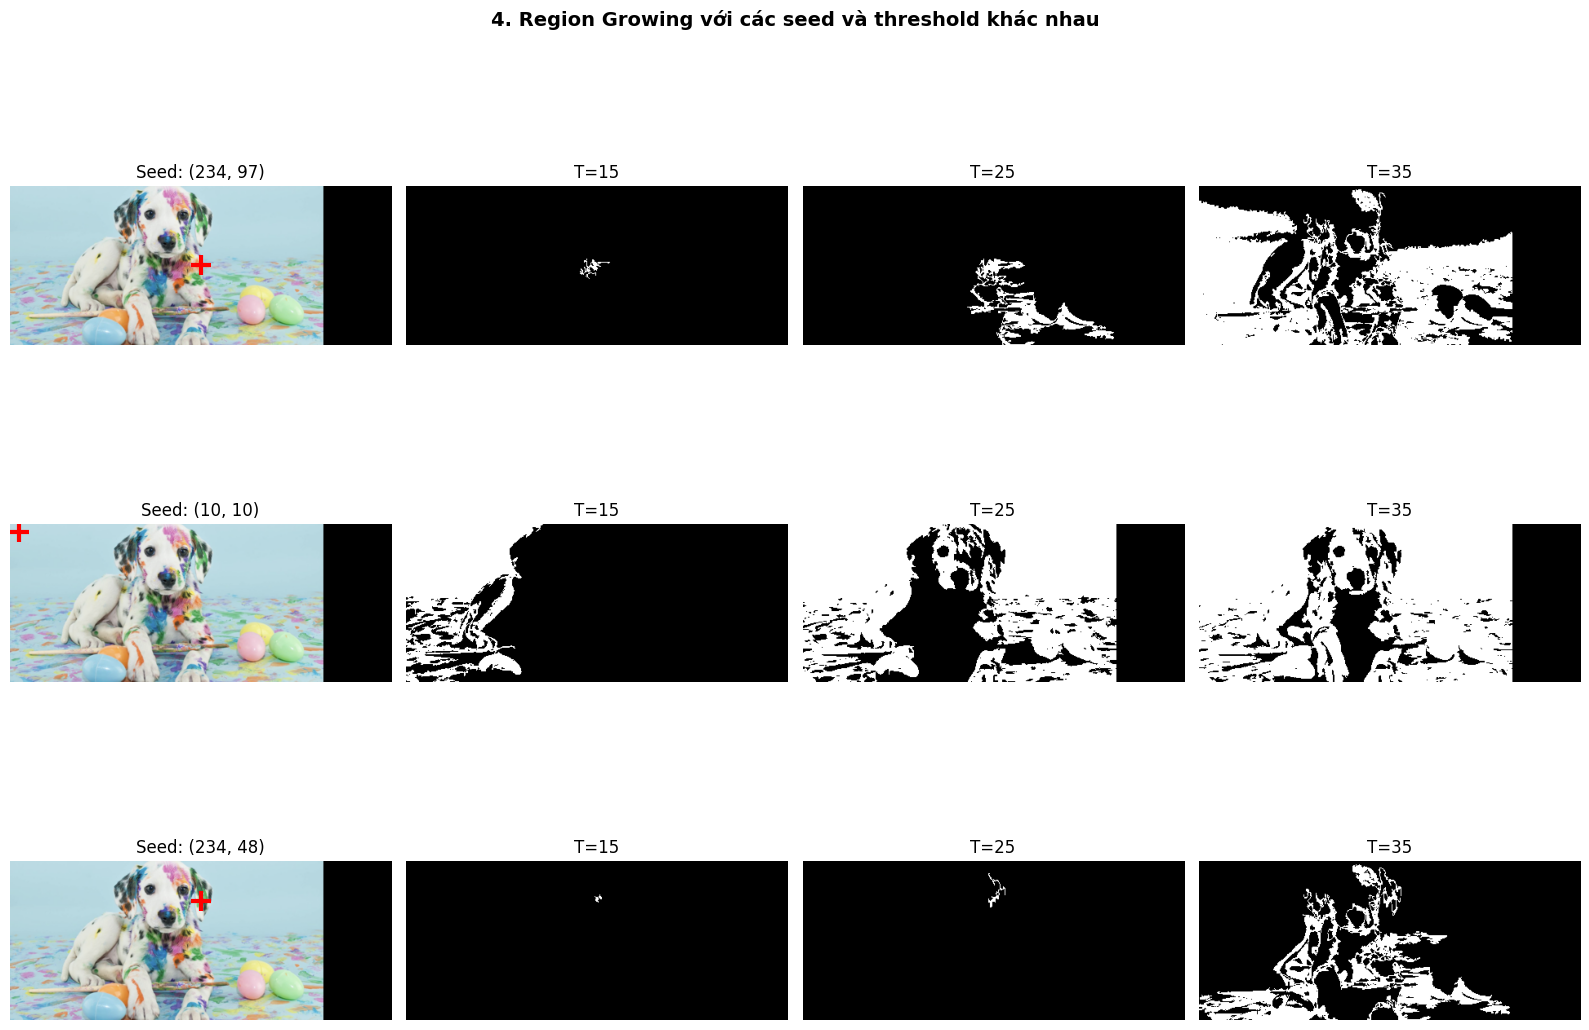

In [7]:
def region_growing(img, seed, threshold=15):
    """Region growing algorithm"""
    h, w = img.shape[:2]
    if len(img.shape) == 3:
        visited = np.zeros((h, w), dtype=bool)
        segmented = np.zeros((h, w), dtype=np.uint8)
        seed_val = img[seed[1], seed[0]].astype(np.float64)
    else:
        visited = np.zeros((h, w), dtype=bool)
        segmented = np.zeros((h, w), dtype=np.uint8)
        seed_val = float(img[seed[1], seed[0]])
    
    queue = deque([seed])
    visited[seed[1], seed[0]] = True
    
    while queue:
        x, y = queue.popleft()
        segmented[y, x] = 255
        
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < w and 0 <= ny < h and not visited[ny, nx]:
                visited[ny, nx] = True
                if len(img.shape) == 3:
                    diff = np.sqrt(np.sum((img[ny, nx].astype(np.float64) - seed_val) ** 2))
                else:
                    diff = abs(float(img[ny, nx]) - seed_val)
                if diff < threshold:
                    queue.append((nx, ny))
    return segmented

# Chọn seed points
h, w = gray.shape
seeds = [(w//2, h//2), (10, 10), (w//2, h//4)]
thresholds = [15, 25, 35]

fig, axes = plt.subplots(len(seeds), len(thresholds) + 1, figsize=(16, 12))
for i, seed in enumerate(seeds):
    axes[i, 0].imshow(img_rgb); axes[i, 0].plot(seed[0], seed[1], 'r+', markersize=15, markeredgewidth=3)
    axes[i, 0].set_title(f'Seed: {seed}'); axes[i, 0].axis('off')
    for j, thresh in enumerate(thresholds):
        result = region_growing(gray, seed, thresh)
        axes[i, j+1].imshow(result, cmap='gray')
        axes[i, j+1].set_title(f'T={thresh}'); axes[i, j+1].axis('off')

plt.suptitle('4. Region Growing với các seed và threshold khác nhau', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Split and Merge

Chia ảnh thành các khối (quadtree), nếu khối không đồng nhất thì chia tiếp. Sau đó gộp các khối lân cận có tính chất tương tự.

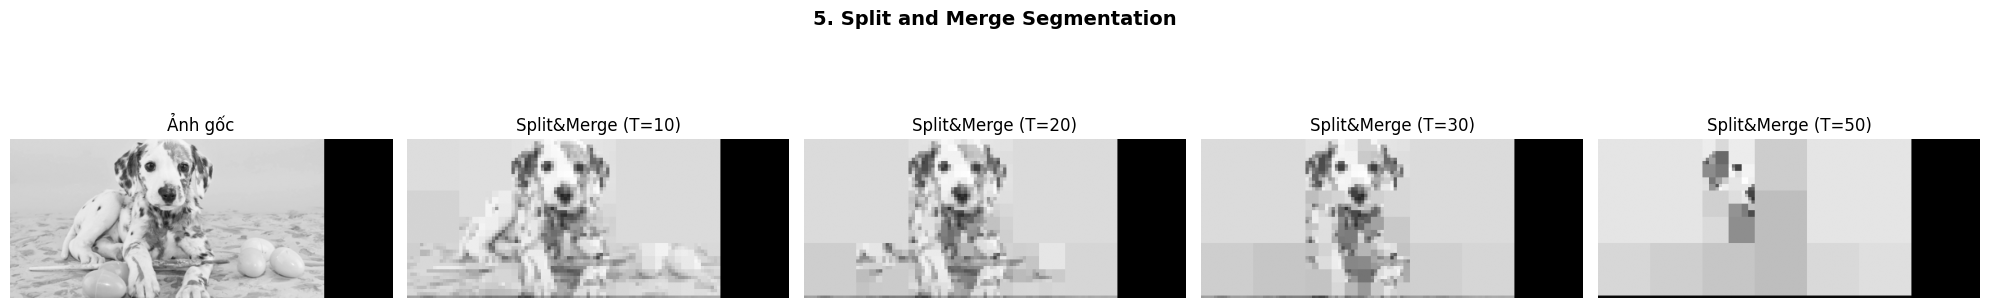

In [8]:
def is_homogeneous(region, threshold=20):
    """Kiểm tra vùng có đồng nhất không"""
    if region.size == 0:
        return True
    return np.std(region) < threshold

def split_and_merge(img, threshold=20, min_size=8):
    """Split and Merge algorithm using quadtree"""
    h, w = img.shape
    output = np.zeros_like(img)
    
    def split(x, y, size):
        region = img[y:y+size, x:x+size]
        if size <= min_size or is_homogeneous(region, threshold):
            output[y:y+size, x:x+size] = np.mean(region)
        else:
            half = size // 2
            if half > 0:
                split(x, y, half)
                split(x + half, y, half)
                split(x, y + half, half)
                split(x + half, y + half, half)
    
    # Resize to power of 2
    size = 2 ** int(np.ceil(np.log2(max(h, w))))
    padded = np.zeros((size, size), dtype=np.uint8)
    padded[:h, :w] = img[:min(h,size), :min(w,size)]
    output_padded = np.zeros_like(padded)
    
    def split_padded(x, y, s):
        region = padded[y:y+s, x:x+s]
        if s <= min_size or is_homogeneous(region, threshold):
            output_padded[y:y+s, x:x+s] = np.mean(region)
        else:
            half = s // 2
            if half > 0:
                split_padded(x, y, half)
                split_padded(x+half, y, half)
                split_padded(x, y+half, half)
                split_padded(x+half, y+half, half)
    
    split_padded(0, 0, size)
    return output_padded[:h, :w]

# Thử các threshold khác nhau
thresholds_sm = [10, 20, 30, 50]
fig, axes = plt.subplots(1, len(thresholds_sm) + 1, figsize=(20, 4))
axes[0].imshow(gray, cmap='gray'); axes[0].set_title('Ảnh gốc'); axes[0].axis('off')

for i, t in enumerate(thresholds_sm):
    result = split_and_merge(gray, threshold=t, min_size=4)
    axes[i+1].imshow(result, cmap='gray'); axes[i+1].set_title(f'Split&Merge (T={t})'); axes[i+1].axis('off')

plt.suptitle('5. Split and Merge Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Edge-based Segmentation

Phát hiện biên (edge) của đối tượng rồi dùng biên để phân đoạn.

Các bộ lọc phổ biến: Sobel, Laplacian, Canny.

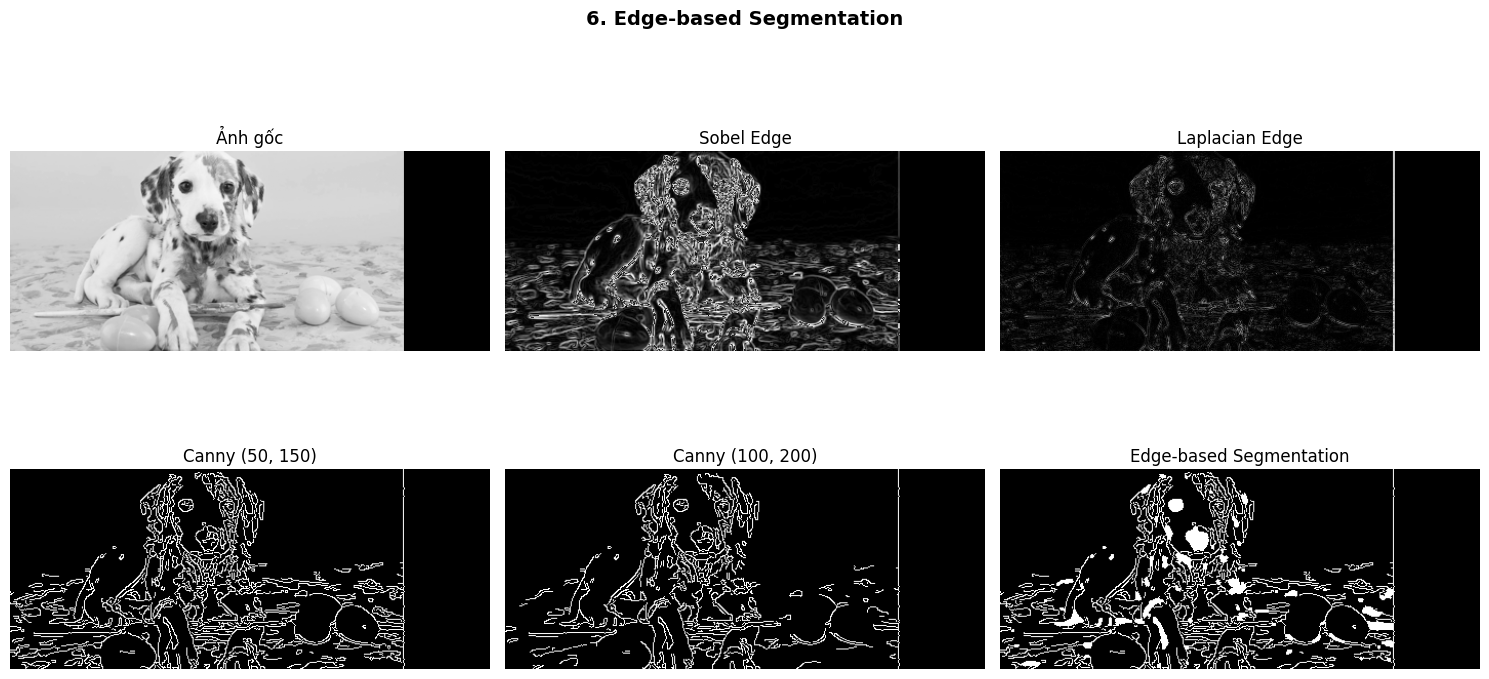

In [9]:
# Edge Detection methods
sobel_x = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
sobel_y = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
sobel = np.sqrt(sobel_x**2 + sobel_y**2).astype(np.uint8)

laplacian = cv.Laplacian(gray, cv.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

canny = cv.Canny(gray, 50, 150)
canny_tight = cv.Canny(gray, 100, 200)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0,0].imshow(gray, cmap='gray'); axes[0,0].set_title('Ảnh gốc')
axes[0,1].imshow(sobel, cmap='gray'); axes[0,1].set_title('Sobel Edge')
axes[0,2].imshow(laplacian, cmap='gray'); axes[0,2].set_title('Laplacian Edge')
axes[1,0].imshow(canny, cmap='gray'); axes[1,0].set_title('Canny (50, 150)')
axes[1,1].imshow(canny_tight, cmap='gray'); axes[1,1].set_title('Canny (100, 200)')

# Edge-based segmentation: dùng Canny + contour filling
contours, _ = cv.findContours(canny, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
edge_seg = np.zeros_like(gray)
cv.drawContours(edge_seg, contours, -1, 255, -1)
axes[1,2].imshow(edge_seg, cmap='gray'); axes[1,2].set_title('Edge-based Segmentation')

for ax in axes.flat: ax.axis('off')
plt.suptitle('6. Edge-based Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

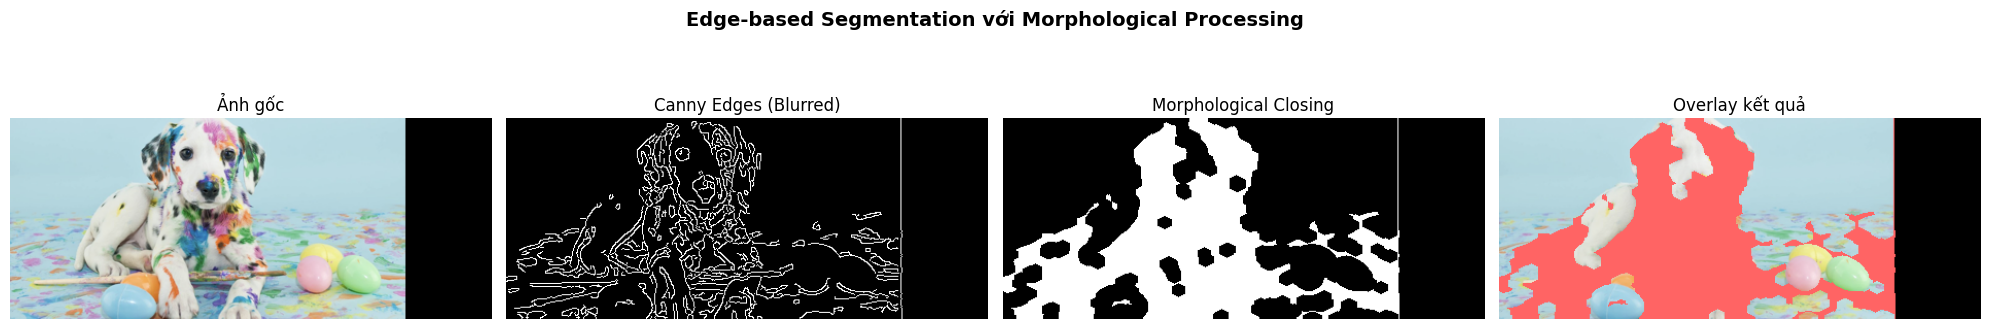

In [10]:
# So sánh Edge-based với Morphological closing
blur_img = cv.GaussianBlur(gray, (5, 5), 0)
edges = cv.Canny(blur_img, 30, 100)

kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
closed = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel, iterations=3)

contours2, _ = cv.findContours(closed, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
filled = np.zeros_like(gray)
cv.drawContours(filled, contours2, -1, 255, -1)

# Overlay
overlay = img_rgb.copy()
overlay[filled == 255] = [255, 100, 100]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Ảnh gốc')
axes[1].imshow(edges, cmap='gray'); axes[1].set_title('Canny Edges (Blurred)')
axes[2].imshow(closed, cmap='gray'); axes[2].set_title('Morphological Closing')
axes[3].imshow(overlay); axes[3].set_title('Overlay kết quả')
for ax in axes: ax.axis('off')
plt.suptitle('Edge-based Segmentation với Morphological Processing', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()